In [ ]:
#!pip install tslearn

## NOTE TO SELF: CHANGE DIRECTORIES TO BE ON GOOGLE DRIVE?? OR GITHUB? ALSO REMOVE OUTPUTS FROM RUN CODE

## Import Packages

In [ ]:
import numpy as np
import os
import pandas as pd
import geopandas as gpd
import scipy
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score
import timeit
import math
import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.cluster import KMeans
import kneed
from osgeo import gdal
from google.colab import files
import geemap
import ee
from google.colab import drive
# Installs geemap package
import subprocess
try:
    import geemap
except ImportError:
    print('geemap package not installed. Installing ...')
    subprocess.check_call(["python", '-m', 'pip', 'install', 'geemap'])


# Preprocess data from Google Earth Engine with time series values per pixel

## Extract time series from downloaded raster(s)

In [ ]:
## Change directory to location of study area data
os.getcwd()
os.chdir("D:\\Peeling\\NMData\\StudyArea")

#identify files to merge
file1 = 'StudyArea_NLCDgrass_obsResid_CorrectedImagery_1985_2023_1.tif'
file2 = 'StudyArea_NLCDgrass_obsResid_CorrectedImagery_1985_2023_2.tif'
raster_file_list = [file1, file2]
#filename of merged images
mergedName = file1[0:-6] + "_merged.tif"

##function to merge rasters together
def merge_rasters(raster_file_list): ## Adding width and height as custom parameters if want to change the size of raster
    output_file = os.path.join(mergedName)
    ds_lst = list()
    for raster in raster_file_list:
        ds = gdal.Warp('', raster, format='vrt', dstNodata=0,
                       dstSRS="+proj=longlat +datum=WGS84 +no_defs +ellps=WGS84 +towgs84=0,0,0")
        ds_lst.append(ds)
        del ds
    dataset = gdal.BuildVRT('', ds_lst, VRTNodata=0, srcNodata=0)
    ds1 = gdal.Translate(output_file, dataset)
    del ds1
    del dataset
    return output_file

#enact function and merge rasters
output_file = mergedName
vrt_file = "merged.vrt"
gdal.BuildVRT(vrt_file,raster_file_list)

# Translate VRT to TIFF
gdal.Translate(output_file,vrt_file)

##get longitude and latitude data to input into CSV
file_name = output_file
with rio.open(file_name) as src:
    band1 = src.read(1)
    print('Band1 has shape', band1.shape)
    height = band1.shape[0]
    width = band1.shape[1]
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    xs, ys = rio.transform.xy(src.transform, rows, cols)
    lons= np.array(xs)
    lats = np.array(ys)
    print('lons shape', lons.shape)

##flatten longitude and latitude data into 1D array
lons_f = lons.flatten()
lats_f = lats.flatten()

## get array of merged raster
ras_comb = rio.open(output_file)
ras_comb_arr = ras_comb.read()

## reshape raster array to have correct dimensions for a dataframe
ras_comb_arr_reshape = ras_comb_arr.reshape((39,7483*2238)) ## in shape: (years, pixels); 39 years (1985-2023)

#create dataframe from reshaped raster array and transpose to be in correct format for clustering
rasDF = pd.DataFrame(ras_comb_arr_reshape).transpose()

#remove NAN values from dataframe
rasDF_clean = rasDF.dropna()

##add longitude and latitude to dataframe
rasDF["lon"] = lons_f
rasDF["lat"] = lats_f

##save dataframe as CSV
output_csv = output_file[0:-4] + ".csv"
rasDF.to_csv(output_csv)

## Clean and scale time series data

In [ ]:
## Set working directory to location of file
os.getcwd()
os.chdir("D:\\Peeling\\NMData\\StudyArea")

## import csv file with data and coordinates
geoDF = pd.read_csv(output_csv)

##remove any NaN values from dataframe (although there should not be any) and drop lon, lat, and copied index columns for time series dataframe
geoDF_clean = geoDF.dropna()
geoDF_ts = geoDF_clean.drop(columns = ["lon","lat","Unnamed: 0","index"])

## scale data (by time series) using min-max normalization
scaled_arr = MinMaxScaler().fit_transform(geoDF_ts.transpose()) #transpose dataframe so each time series is scaled by its own min and max
##convert back to dataframe and original format
df_T_scaled = pd.DataFrame(scaled_arr, index = geoDF_ts.transpose().index)
# convert data back to rows
df_scaled = df_T_scaled.transpose()
ndvi_arr = df_scaled.to_numpy()

# Run and plot time series clustering

In [ ]:
## Finding the Optimal Number of Clusters through within-cluster distance to center
ssd = []
range_n_clusters = np.arange(2,100)
for num_clusters in range_n_clusters:
    print(num_clusters)
    kmeans = KMeans(n_clusters = num_clusters, random_state = 0)
    kmeans.fit(ndvi_arr)

    ssd.append(kmeans.inertia_)
plt.plot(ssd)
plt.xlabel("Clusters")
plt.ylabel("SSD")
#plt.savefig("clusterSSD_grasslands19852023_2_100.png")
ssd_df = pd.DataFrame(ssd)
#ssd_df.to_csv("clusterSSD_grasslands_2_100.csv")

In [ ]:
## Use kneed algorithm to implement kneedle function to find point of maximum curvature
kn = kneed.KneeLocator(
    x,
    y,
    #S = 10,
    curve='convex',
    direction='decreasing',
    interp_method='interp1d',
    #interp_method='polynomial'
)

print(kn.knee)

In [ ]:
##figure out appropriate number of iterations (using 20 clusters)
num_clusters = 20
km_iters = KMeans(n_clusters=num_clusters, max_iter=500, n_init = 1, tol = 1e-6,
                          random_state=0)
%time km_iters_fit = km_iters.fit(ndvi_arr)
# ## see how many iterations
print(km_iters_fit.n_iter_)
iters = km_iters_fit.n_iter_

CPU times: total: 5min 55s
Wall time: 47.7 s
140


In [ ]:
## run k-means clustering with multiple initializations
num_clusters = 20
n_inits = 3
km = KMeans(n_clusters=num_clusters, max_iter=iters, n_init = n_inits,
                          random_state=0)
%time km_fit = km.fit(ndvi_arr)

###Note: need to figure out how many clusters would be best

CPU times: total: 16min 7s
Wall time: 2min 14s


In [ ]:
silhouette_score(ndvi_arr, km_dtw_fit.labels_)

In [ ]:
## Look at properties of the clustering
km_fit.cluster_centers_.shape
np.unique(km_fit.labels_)

In [ ]:
## Recreate dataframe and transpose it
df = pd.DataFrame(ndvi_arr.reshape(geoDF_ts.shape), columns=np.arange(1985,2024), index=geoDF_ts.index)
df_T = df.transpose()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


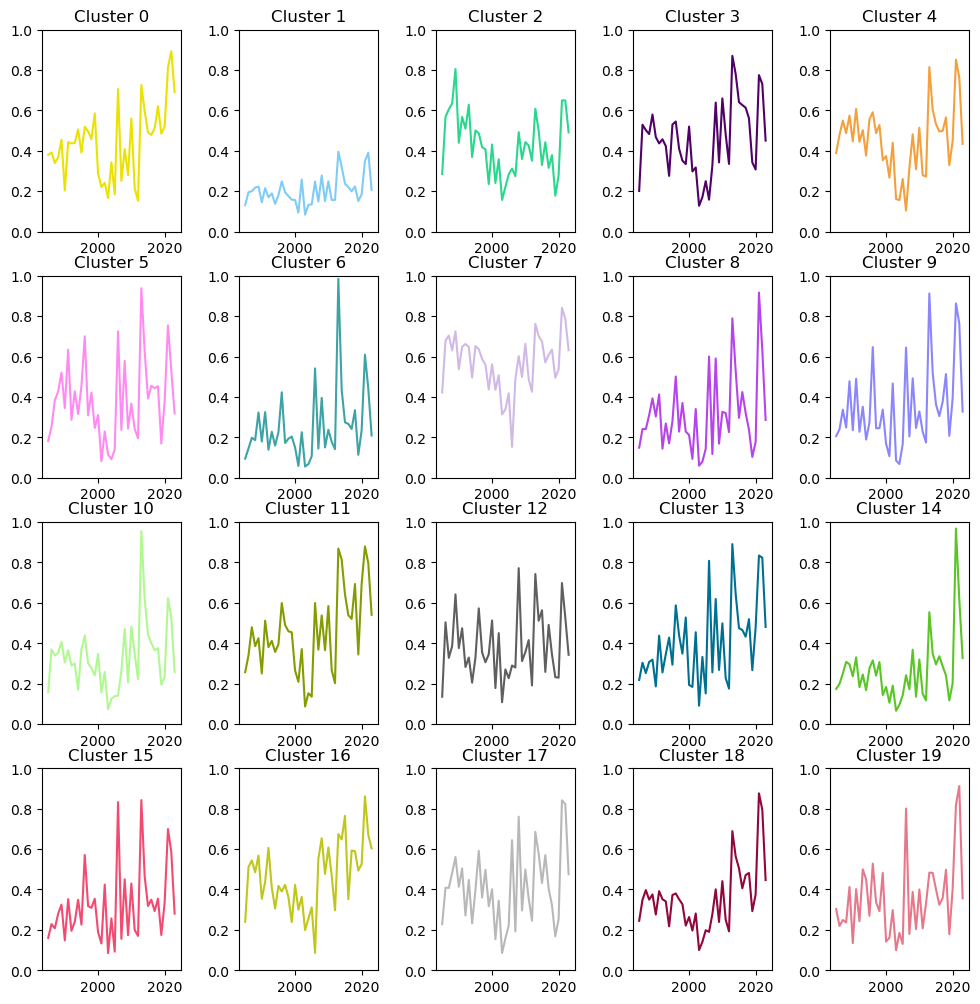

In [ ]:
## Create plots of all the mean cluster trajectories (Note that these plots are based on min-max scaled values)
num_clusters = 20
colors = ["#eae200", "#7fccf6","#2bd78d","#510068","#f4a03c","#ff8bf2","#3da3a5","#d1b9e7","#b744eb","#8b86fc","#b1f892","#859c00","#5f5f5f","#007092",
          "#59c626","#f24a71","#bfc71b","#b8b8b8","#91063c","#e7788c"]
rows = int(math.sqrt(num_clusters))
cols = math.ceil(math.sqrt(num_clusters))
plt.Figure(figsize =(10,5))
fig, axs = plt.subplots(int(math.sqrt(num_clusters)), math.ceil(math.sqrt(num_clusters)), figsize = (10,10))
fig.tight_layout()
cluster_number = 0
for i in np.arange(0,rows):
    for j in np.arange(0,cols):
        mean_ts = df_T[cluster_metrics_dict[cluster_number]].mean(axis = 1)
        print(cluster_number)
        axs[i,j].plot(mean_ts, colors[cluster_number])
        axs[i,j].set_title("Cluster "+ str(cluster_number+1))
        axs[i,j].set_ylim(0,1)
        cluster_number = cluster_number + 1
        if cluster_number == num_clusters:
            break
#plt.savefig("StudyArea_OR_1985_2023_kmeans_clusterMeans_n20.png")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


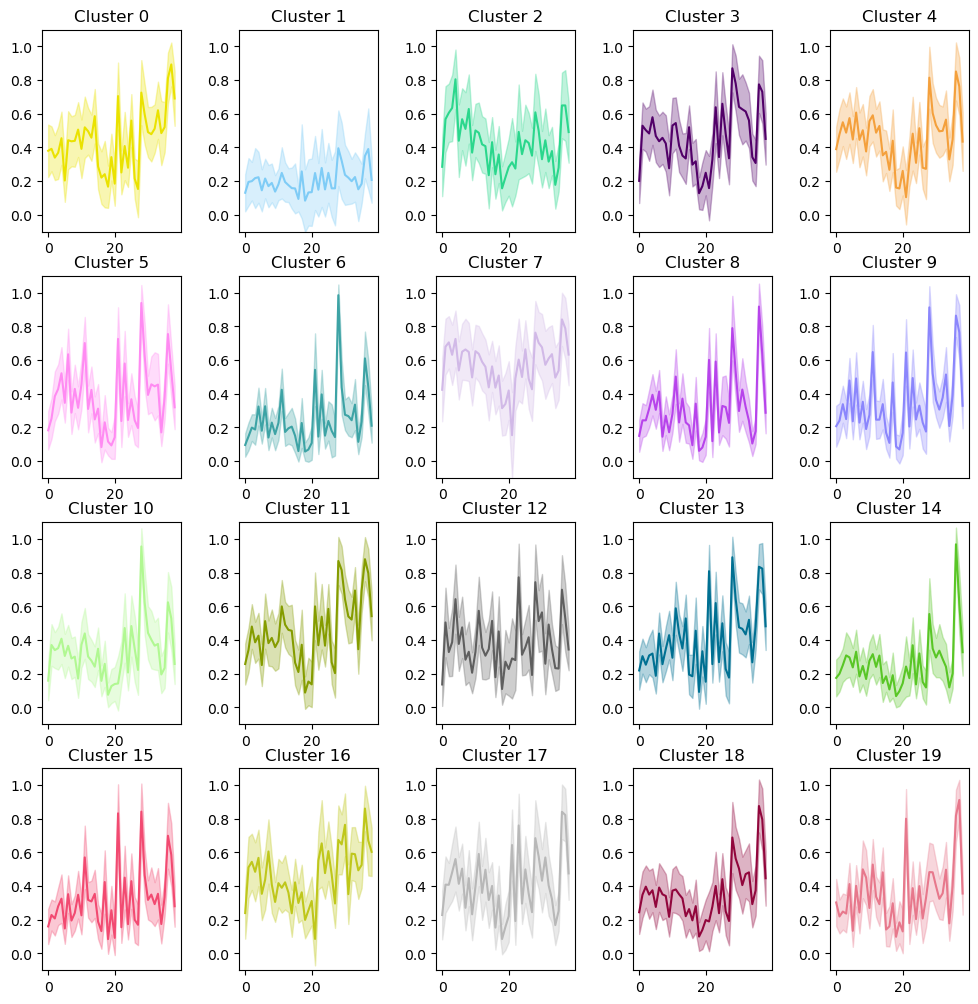

In [ ]:
## Create plots of all the mean cluster trajectories with one standard deviation (Note that these plots are based on min-max scaled values)
num_clusters = 20
colors = ["#eae200", "#7fccf6","#2bd78d","#510068","#f4a03c","#ff8bf2","#3da3a5","#d1b9e7","#b744eb","#8b86fc","#b1f892","#859c00","#5f5f5f","#007092"
          ,"#59c626","#f24a71","#bfc71b","#b8b8b8","#91063c","#e7788c"]
rows = int(math.sqrt(num_clusters))
cols = math.ceil(math.sqrt(num_clusters))
plt.Figure(figsize =(10,8))
fig, axs = plt.subplots(int(math.sqrt(num_clusters)), math.ceil(math.sqrt(num_clusters)), figsize = (10,10))
fig.tight_layout()
cluster_number = 0
for i in np.arange(0,rows):
    for j in np.arange(0,cols):
        df_conf = df_T[cluster_metrics_dict[cluster_number]].transpose()
        mean, lower, upper = [],[],[]
        for col in df_conf.columns:
            a = df_conf[col]
            m = np.mean(a)
            ml = m-np.std(a)
            mu = m + np.std(a)
            mean.append(m)
            lower.append(ml)
            upper.append(mu)
        mean_ts = df_T[cluster_metrics_dict[cluster_number]].mean(axis = 1)
        print(cluster_number)
        axs[i,j].plot(mean,color=colors[cluster_number], label='mean')
        #axs[i,j].plot(upper,'-r', label='upper')
        #axs[i,j].plot(lower,'-g', label='lower')
        axs[i,j].fill_between(list(range(len(mean))), upper, lower, color=colors[cluster_number], alpha=0.3)
        axs[i,j].set_title("Cluster "+ str(cluster_number+1))
        axs[i,j].set_ylim(-0.1,1.1)
        cluster_number = cluster_number + 1
        if cluster_number == num_clusters:
            break
#plt.savefig("StudyArea_OR_1985_2023_kmeans_clusterStdev_n20.png")

## Evaluate Model Performance

In [ ]:
## Calculate silhouette score
labels = km_fit.labels_
%time sil = silhouette_score(ndvi_arr, labels, random_state = 17)
print(sil)

# Map the pixels back into space with the cluster assignment

In [ ]:
## reset index to 0 of dataframe
geoDF_reset = geoDF_clean.reset_index(drop=True)
#add cluster information to dataframe
geoDF_reset['cluster'] = df_cluster["cluster"]
##drop "unnamed:0" column
geoDF_reset = geoDF_reset.drop(columns = "Unnamed: 0")
##rename "index" column to "pixel"
geoDF_reset = geoDF_reset.rename(columns = {"index":"pixel"})

,Unnamed: 0,index,1,2,3,4,5,6,7,8,...,32,33,34,35,36,37,38,39,lon,lat
0,0,43,-0.017225,0.024246,-0.029724,-0.041005,0.010980,0.015387,0.018991,-0.004081,...,-0.045149,-0.035268,0.040939,0.029044,-0.028042,0.038295,0.036867,0.005419,-107.083000,34.424295
1,1,44,-0.040163,-0.003856,-0.016011,-0.023281,-0.004529,0.004982,0.003986,-0.016493,...,-0.041108,-0.032537,0.033146,0.026900,-0.019364,0.032242,0.044654,0.027007,-107.082730,34.424295
2,2,45,-0.018541,0.010345,-0.033689,-0.036985,-0.007426,0.026014,0.008701,0.005166,...,-0.018356,-0.037813,0.026177,0.032840,-0.013438,0.026730,0.037399,0.021678,-107.082461,34.424295
3,3,46,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,...,-0.026866,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,-107.082191,34.424295
4,4,47,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,...,-0.026866,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,-107.081922,34.424295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11986624,11986624,16746768,-0.134445,0.003741,-0.042067,-0.067792,0.202568,0.100814,0.066263,-0.061525,...,0.079261,0.051328,-0.070307,-0.041779,-0.064214,0.152726,0.080818,-0.028686,-106.541585,32.407937
11986625,11986625,16746769,-0.138449,-0.010015,-0.059205,-0.066640,0.182919,0.085199,0.059347,-0.059903,...,0.074015,0.069315,-0.037221,-0.039513,-0.061224,0.181662,0.084254,-0.021542,-106.541316,32.407937
11986626,11986626,16746770,-0.139723,-0.019727,-0.065401,-0.062303,0.135619,0.051942,0.040290,-0.068516,...,0.084478,0.081682,-0.002910,-0.028698,-0.059051,0.186046,0.094584,-0.012356,-106.541046,32.407937
11986627,11986627,16746771,-0.131654,-0.021117,-0.041873,-0.061583,0.118544,0.041457,0.017150,-0.078645,...,0.083864,0.071761,-0.015173,-0.032548,-0.057449,0.191230,0.086292,-0.019185,-106.540777,32.407937


In [ ]:
## convert column names to years
year = 1985
for column in geoDF_reset.columns[1:40]:
    geoDF_reset = geoDF_reset.rename(columns = {str(column): str(year)})
    year = year + 1

,pixel,1985,1986,1987,1988,1989,1990,1991,1992,1993,...,2017,2018,2019,2020,2021,2022,2023,lon,lat,cluster
0,43,-0.017225,0.024246,-0.029724,-0.041005,0.010980,0.015387,0.018991,-0.004081,0.033703,...,-0.035268,0.040939,0.029044,-0.028042,0.038295,0.036867,0.005419,-107.083000,34.424295,0
1,44,-0.040163,-0.003856,-0.016011,-0.023281,-0.004529,0.004982,0.003986,-0.016493,0.040544,...,-0.032537,0.033146,0.026900,-0.019364,0.032242,0.044654,0.027007,-107.082730,34.424295,0
2,45,-0.018541,0.010345,-0.033689,-0.036985,-0.007426,0.026014,0.008701,0.005166,0.016052,...,-0.037813,0.026177,0.032840,-0.013438,0.026730,0.037399,0.021678,-107.082461,34.424295,0
3,46,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,0.017988,...,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,-107.082191,34.424295,0
4,47,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,0.017988,...,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,-107.081922,34.424295,0


In [ ]:
##save to CSV
geoDF_reset.to_csv('StudyArea_OR_1985_2023_clustered_kmeans_n20.csv', index = False)

In [ ]:
#import and read base raster file
os.getcwd()
os.chdir("D:\\Peeling\\NMData\\StudyArea")
ras_file = "StudyArea_NLCDgrass_OR_CorrectedImagery_merged.tif" ## change this variable
ras = rasterio.open(ras_file)

## convert csv to geodataframe
gdf = gpd.GeoDataFrame(geoDF_reset, geometry=gpd.points_from_xy(geoDF_reset['lon'], geoDF_reset['lat']), crs="EPSG:4326")

## create a rasterized version of the shapefile
## create tuples of geometry, value pairs, where value is the attribute value you want to burn
shp = gdf
geom_value = ((geom,value) for geom, value in zip(shp.geometry, shp['cluster']))

## Rasterize vector using the shape and transform of the raster
rasterized = features.rasterize(geom_value,
                                out_shape = ras.shape,
                                transform = ras.transform,
                                all_touched = True,
                                fill = -5,   # background value
                                merge_alg = MergeAlg.replace,
                                dtype = int16)
# Save rasterized vector as a raster
outputFile = "StudyArea_OR_1985_2023_clustered_kmeans_n20.tif"
with rasterio.open(
        #"test_medium2\\NM_residsObs_clustered_normScaled_n7_SCLfixed.tif", "w", ##test
        outputFile, "w", ##study area
        driver = "GTiff",
        crs = ras.crs,
        transform = ras.transform,
        dtype = rasterio.uint8,
        count = 1,
        width = ras.width,
        height = ras.height) as dst:
    dst.write(rasterized, indexes = 1)

## Create Unscaled Plots

In [ ]:
## import file with clusters
clusterDF = geoDF_reset

In [ ]:
cDF_T = clusterDF.drop(columns = ["pixel","lat","lon","cluster"]).transpose()
labels = clusterDF["cluster"]

In [ ]:
## from https://andrewm4894.com/2020/09/03/time-series-clustering-with-tslearn/
## Build helper df to map metrics to their cluster label
df_cluster = pd.DataFrame(list(zip(cDF_T.columns, labels)), columns=['pixel', 'cluster'])

## Make some helper dictionaries and lists
cluster_metrics_dict = df_cluster.groupby(['cluster'])['pixel'].apply(lambda x: [x for x in x]).to_dict()
cluster_len_dict = df_cluster['cluster'].value_counts().to_dict()
clusters_dropped = [cluster for cluster in cluster_len_dict if cluster_len_dict[cluster]==1]
clusters_final = [cluster for cluster in cluster_len_dict if cluster_len_dict[cluster]>1]
clusters_final.sort()


,pixel,cluster
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


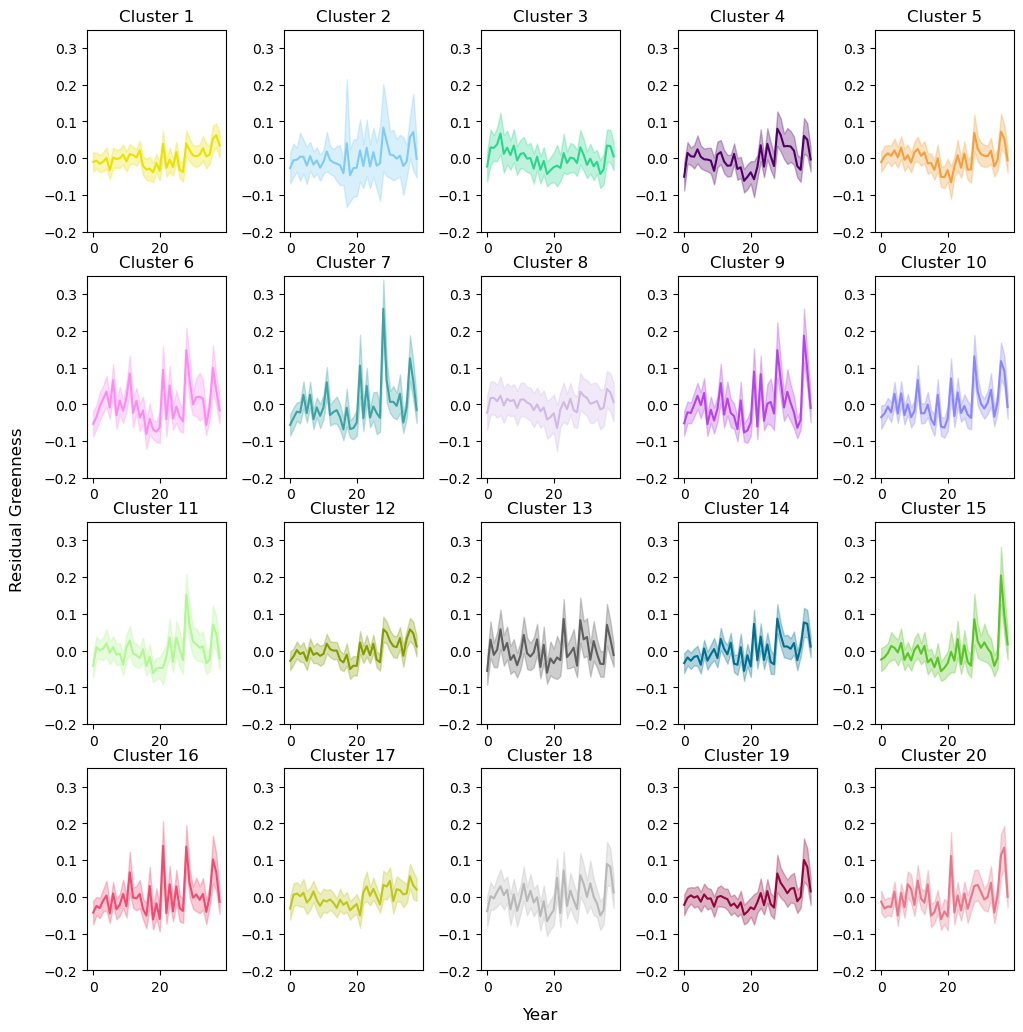

In [ ]:
## Create plots of all the mean cluster trajectories with one standard deviation
num_clusters = 20
colors = ["#eae200", "#7fccf6","#2bd78d","#510068","#f4a03c","#ff8bf2","#3da3a5","#d1b9e7","#b744eb","#8b86fc","#b1f892","#859c00","#5f5f5f","#007092"
          ,"#59c626","#f24a71","#bfc71b","#b8b8b8","#91063c","#e7788c"]
rows = int(math.sqrt(num_clusters))
cols = math.ceil(math.sqrt(num_clusters))
plt.Figure(figsize =(10,8))
fig, axs = plt.subplots(int(math.sqrt(num_clusters)), math.ceil(math.sqrt(num_clusters)), figsize = (10,10))
fig.tight_layout()
cluster_number = 0
for i in np.arange(0,rows):
    for j in np.arange(0,cols):
        df_conf = cDF_T[cluster_metrics_dict[cluster_number]].transpose()
        mean, lower, upper = [],[],[]
        for col in df_conf.columns:
            a = df_conf[col]
            m = np.mean(a)
            ml = m-np.std(a)
            mu = m + np.std(a)
            mean.append(m)
            lower.append(ml)
            upper.append(mu)
        mean_ts = cDF_T[cluster_metrics_dict[cluster_number]].mean(axis = 1)
        print(cluster_number)
        axs[i,j].plot(mean,color=colors[cluster_number], label='mean')
        #axs[i,j].plot(upper,'-r', label='upper')
        #axs[i,j].plot(lower,'-g', label='lower')
        axs[i,j].fill_between(list(range(len(mean))), upper, lower, color=colors[cluster_number], alpha=0.3)
        axs[i,j].set_title("Cluster "+ str(cluster_number+1))
        axs[i,j].set_ylim(-0.2,0.35)
        cluster_number = cluster_number + 1
        if cluster_number == num_clusters:
            break
fig.text(0.5,-0.01,'Year', ha='center', fontsize = 12)
fig.text(-0.03, 0.5, 'Residual Greenness', va='center', rotation='vertical', fontsize = 12)
#plt.savefig("StudyArea_OR_1985_2023_kmeans_clusterStdev_n20_unscaled.png",bbox_inches='tight')

## Get Cluster Means for LandTrendr

In [ ]:
## get pixel-wise time series
clusterDF_ts = clusterDF[clusterDF.columns[1:40]] ## just the years
clusterDF_ts["cluster"] = clusterDF["cluster"]

C:\Users\jap479\AppData\Local\Temp\ipykernel_39460\789011050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusterDF_ts["cluster"] = clusterDF["cluster"]


,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,cluster
0,-0.017225,0.024246,-0.029724,-0.041005,0.010980,0.015387,0.018991,-0.004081,0.033703,-0.018413,...,0.028342,-0.045149,-0.035268,0.040939,0.029044,-0.028042,0.038295,0.036867,0.005419,0
1,-0.040163,-0.003856,-0.016011,-0.023281,-0.004529,0.004982,0.003986,-0.016493,0.040544,0.000483,...,0.030334,-0.041108,-0.032537,0.033146,0.026900,-0.019364,0.032242,0.044654,0.027007,0
2,-0.018541,0.010345,-0.033689,-0.036985,-0.007426,0.026014,0.008701,0.005166,0.016052,-0.015593,...,0.011227,-0.018356,-0.037813,0.026177,0.032840,-0.013438,0.026730,0.037399,0.021678,0
3,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,0.017988,-0.009181,...,0.018668,-0.026866,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,0
4,-0.018427,0.005830,-0.013167,-0.044376,0.008902,0.011615,0.025893,-0.005612,0.017988,-0.009181,...,0.018668,-0.026866,-0.033962,0.026304,0.017224,-0.014924,0.022666,0.041038,0.029144,0


In [ ]:
## get the mean time series of each cluster
clusterMeans = clusterDF_ts.groupby(['cluster']).mean()

,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.010431,-0.007054,-0.015544,-0.009895,0.000370,-0.033055,0.001106,-0.002476,-0.000621,0.009098,...,0.021352,0.007321,0.004760,0.009020,0.026730,0.004412,0.009404,0.052864,0.062503,0.034097
1,-0.027473,-0.005737,-0.004590,0.003747,0.003648,-0.020312,0.005193,-0.017631,-0.006431,-0.026136,...,0.045523,0.009495,0.007750,-0.001429,0.006439,-0.021652,-0.010027,0.056958,0.070903,-0.002277
2,-0.022783,0.028896,0.027722,0.037366,0.066695,0.011483,0.028290,0.008089,0.033865,-0.006568,...,0.008576,-0.018440,-0.001787,-0.022261,-0.010276,-0.043319,-0.030826,0.033991,0.032758,0.004676
3,-0.050665,0.013978,0.004906,0.003565,0.023822,0.003248,-0.003421,-0.004112,-0.006993,-0.034909,...,0.063049,0.031865,0.032883,0.031569,0.019968,-0.021970,-0.031880,0.060383,0.050021,-0.003855
4,-0.011116,0.004898,0.012983,0.006289,0.020999,0.001770,0.028603,-0.004782,0.007789,-0.012140,...,0.025667,0.010626,0.006236,0.005362,0.020019,-0.022927,-0.004582,0.072060,0.053462,-0.006269
5,-0.053118,-0.034547,-0.005218,0.014203,0.034456,-0.008982,0.065766,-0.029884,0.010686,-0.017621,...,0.065324,-0.000259,0.019493,0.020904,0.015799,-0.056406,-0.007153,0.099083,0.038092,-0.016696
6,-0.055827,-0.037484,-0.019954,-0.022289,0.025901,-0.024095,0.026157,-0.040757,-0.008423,-0.031559,...,0.064546,0.006538,0.006736,-0.004335,0.028990,-0.049608,-0.008008,0.125297,0.063734,-0.015786
7,-0.022802,0.016857,0.017389,0.008477,0.023424,-0.003030,0.015152,0.008554,0.011993,-0.010157,...,0.023447,0.017021,0.001544,0.004419,0.009305,-0.013826,-0.009293,0.041825,0.032508,0.006079
8,-0.051679,-0.021490,-0.023609,-0.001365,0.023152,-0.002311,0.030951,-0.054060,-0.014598,-0.044195,...,0.067061,-0.008657,0.034251,0.003531,-0.021932,-0.064162,-0.042774,0.187013,0.094060,-0.009927


In [ ]:
## save the mean cluster time series as a CSV
clusterMeans.to_csv("StudyArea_NLCDgrassland_obsResid_1985_2023_SCL_kmeans_n20_clusterMeans.csv")

In [ ]:
## save the mean cluster time series as a shapefile
# load in shapefile with n clusters grid
os.chdir(r"C:\Users\jap479\Box\Peeling_Research\Shapefiles\StudyArea\GridForLantrendr")
shp = gpd.read_file("GridForLandtrendr_n20.shp")
##create shapefile with cluster means and geometries
shp_filt = shp.drop(columns = shp.columns[0:8])
data_join = shp_filt.join(clusterMeans)
## save file to import to colabs
data_join.to_file("StudyArea_NLCDgrassland_obsResid_1985_2023_SCL_clustered_kmeans_n20_clusterMeans_landtrendrCoords.shp")

## Conduct LandTrendr through GEE API

In [ ]:
##connect to GEE account
ee.Authenticate()
#https://developers.google.com/earth-engine/guides/python_install
ee.Initialize(project='ee-jap479')

## set recursion limit
print(sys.getrecursionlimit())
sys.setrecursionlimit(1000000000)

In [ ]:
## grab files from drive
drive.mount('/content/drive')

## set up aoi
aoi_gdf = gpd.read_file("/content/drive/MyDrive/LandTrendr_ClusterMeans/GridForLandtrendr_n20_extent.shp")
aoi_fc = ee.FeatureCollection('projects/ee-jap479/assets/GridForLandtrendr_n20_extent')
aoi_name = "SA_NLCD_kmeans_clusterMeans_n20"
print(aoi_gdf["geometry"][0])
aoi_coords = [[-106.925210627, 33.271262504414764], [-106.925210627, 33.271531999], ## retrieved from aoi_gdf geometry column
              [-106.91982073529527, 33.271531999],[-106.91982073529527, 33.271262504414764]]
aoi_poly = ee.Geometry.Polygon(aoi_coords)

## import dataframe of cluster means and grid coords
data = gpd.read_file("/content/drive/MyDrive/LandTrendr_ClusterMeans/StudyArea_NLCDgrassland_obsResid_1985_2023_SCL_clustered_kmeans_n20_clusterMeans_landtrendrCoords.shp")
data.head()

# data_df = pd.read_csv("/content/drive/MyDrive/LandTrendr_ClusterMeans/StudyArea_NLCDgrass_obsResid_1985_2023_SCL_kmeans_n20.csv")
# data = gpd.GeoDataFrame(data_df, geometry=gpd.points_from_xy(data_df['lon'], data_df['lat']), crs="EPSG:4326")
# data.head()

In [ ]:
## change magnitude of data so that decimals don't get lost
data[data.columns[0:-3]] = data[data.columns[0:-3]]*1e6
#data = data.drop(columns = ["lat","lon"])
data.head()

## convert data to feature collection
fc = geemap.geopandas_to_ee(data)

## create image collection of the cluster means
images = []
for year in np.arange(1985,2024):
  yr = str(year)
  date = yr+"-01-01"
  image = fc.reduceToImage([yr], ee.Reducer.first()).set("system:time_start",ee.Date(date).millis())
  images.append(image)
imageColl = ee.ImageCollection(images)


In [ ]:
## set up LandTrendr parameters
maxSegments=6
spikeThreshold=0.9
vertexCountOvershoot=3
preventOneYearRecovery = True
recoveryThreshold=0.25
pvalThreshold=0.05
bestModelProportion=0.75
minObservationsNeeded=10

## setup LandTrendr
startYear_Num = 1985
endYear_Num   = 2023;

##run LandTrendr
lt = ee.Algorithms.TemporalSegmentation.LandTrendr(
  timeSeries=imageColl,
  maxSegments=maxSegments,
  spikeThreshold=spikeThreshold,
  vertexCountOvershoot=vertexCountOvershoot,
  preventOneYearRecovery=preventOneYearRecovery,
  recoveryThreshold=recoveryThreshold,
  pvalThreshold=pvalThreshold,
  bestModelProportion=bestModelProportion,
  minObservationsNeeded=minObservationsNeeded)

##extract results from landtrendr
ltlt = lt.select(['LandTrendr'])
years = ltlt.arraySlice(0, 0, 1)
observed = ltlt.arraySlice(0, 1, 2)
rmse = lt.select('rmse')
fitted = ltlt.arraySlice(0, 2, 3)
vertexMask = ltlt.arraySlice(0, 3, 4)
vertices = ltlt.arrayMask(vertexMask)

leftList  = vertices.arraySlice(1, 0, -1)  #slice out the vertices as the start of segments
rightList = vertices.arraySlice(1, 1)   # slice out the vertices as the end of segments
startYear = leftList.arraySlice(0, 0, 1)   #get year dimension of LT data from the segment start vertices
startVal  = leftList.arraySlice(0, 2, 3)      # get FITTED index data from LT at the segment start vertices
endYear   = rightList.arraySlice(0, 0, 1)     # get year dimension of LT data from the segment end vertices
endVal    = rightList.arraySlice(0, 2, 3)     # get FITTED index data from LT at the segment end vertices
dur       = endYear.subtract(startYear)      # subtract the segment start year from the segment end year to calculate the duration of segments
mag       = endVal.subtract(startVal)        # substract the segment start index value from the segment end index value to calculate the delta of segments
rate      = mag.divide(dur)

In [ ]:
## export LandTrendr Results
years = ee.List.sequence(startYear_Num, endYear_Num)
def getYearStr(year):
  return(ee.String('yr_').cat(ee.Algorithms.String(year).slice(0,4)))

yearsStr = years.map(getYearStr)
fittedStack = fitted.arrayFlatten([['fittedMeans'], yearsStr]).toShort();
print(fittedStack.bandNames().getInfo())
fittedStack_ex = fittedStack
drive = ee.batch.Export.image.toDrive(
            image = fittedStack,
            description = "SANLCD_1985_2023_SCL_kmeans_n20",
            crs = "EPSG:4326",
            #assetId='projects/ee-jap479/assets/SANLCD_fitted',
            region = aoi_poly,
            scale = 30
        )
drive.start()

## Visualize LandTrendr Results

In [ ]:
##import image with fitted LandTrendr cluster time series
#os.chdir("C:\\Users\\peeli\\Box\\Peeling_Research\\NMData\\StudyArea")
os.chdir(r"C:\Users\jap479\Box\Peeling_Research\NMData\StudyArea")
ras = "SANLCD_1985_2023_SCL_kmeans_n20.tif"

## open image
LTfit = rasterio.open(ras)
bands = LTfit.read()

cmeans_LT = []
for band in np.arange(1, bands.shape[0]+1):
    info = LTfit.read(int(band))
    vals = info[0][1:] ##for some reason each pixel is doubled, and the first pixel is duplicated so select out only one of each pixel
    cmeans_LT.append(vals/1e6) ## the values were also scaled by 1e6, unscale here

## create dataframe
cmeans_LT_df = pd.DataFrame(cmeans_LT, index = np.arange(1985,2024))
cmeans_LT_df_T = cmeans_LT_df.transpose()



In [ ]:
## Create plots of all the mean cluster trajectories overlaid by LT (unscaled)
num_clusters = 20
colors = ["#eae200", "#7fccf6","#2bd78d","#510068","#f4a03c","#ff8bf2","#3da3a5","#d1b9e7","#b744eb","#8b86fc","#b1f892","#859c00","#5f5f5f","#007092"
          ,"#59c626","#f24a71","#bfc71b","#b8b8b8","#91063c","#e7788c"]
rows = int(math.sqrt(num_clusters))
cols = math.ceil(math.sqrt(num_clusters))
plt.Figure(figsize =(10,5))
fig, axs = plt.subplots(int(math.sqrt(num_clusters)), math.ceil(math.sqrt(num_clusters)), figsize = (10,10))
fig.tight_layout()
cluster_number = 0
for i in np.arange(0,rows):
    for j in np.arange(0,cols):
        mean_ts = cDF_T[cluster_metrics_dict[cluster_number]].mean(axis = 1)
        lt_ts = cmeans_LT_df[cluster_number]
        print(cluster_number)
        axs[i,j].plot(mean_ts, colors[cluster_number])
        axs[i,j].plot(lt_ts, "k",linestyle='--')
        axs[i,j].set_title("Cluster "+ str(cluster_number+1))
        axs[i,j].set_ylim(-0.1,0.3)
        cluster_number = cluster_number + 1
        if cluster_number == num_clusters:
            break
os.chdir("D:\\Peeling\\NMData\\StudyArea")
plt.savefig("StudyArea_NLCDgrass_obsResid_1985_2023_SCL_clustered_kmeans_clusterMeans_LandTrendr_n20_colorMatched_visCheck_cShift.png")